# RAG vs CAG on ACQAD Multi-hop

Simple notebook for running and viewing the experiment results.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))

from utils import (CONFIG, RESULT_DIR, acqad_path, build_subsets, download_acqad_multihop,
                   load_records, summarize_research_questions)
from rag import run_rag
from cag import run_cag

CONFIG

Config(model_id='unsloth/Meta-Llama-3.1-8B-Instruct', tokenizer_id='unsloth/Meta-Llama-3.1-8B-Instruct', embedding_model_id='BAAI/bge-m3', embedding_max_tokens=2048, kaggle_dataset='abdellahhamouda/acqad-dataset', hf_subset_dataset='abdullah-alamodi/acqad-rag-cag-subsets', seed=42, budgets={'small': 30000, 'medium': 60000, 'large': 90000}, rag_top_k=(2, 4, 6, 10), max_new_tokens=300, device_preference='auto', torch_dtype='float16', bertscore_lang='ar')

# Data Analysis

In [2]:
# add the analysis we did in laterature review

In [10]:
from IPython.display import HTML, display
import pandas as pd

# Analyze every record and every context occurrence in the full ACQAD file.
records = load_records(acqad_path())
context_paragraphs = [paragraph for record in records for paragraph in record['context']]
word_counts = pd.Series([len(paragraph.split()) for paragraph in context_paragraphs])

preprocessing_stats = pd.DataFrame([{
    'Dataset': 'ACQAD multi-hop',
    'Total context paragraphs': len(context_paragraphs),
    'Unique paragraphs': len(set(context_paragraphs)),
    'Duplicated paragraph occurrences': len(context_paragraphs) - len(set(context_paragraphs)),
    'Mean words per paragraph': word_counts.mean(),
    'Median words per paragraph': word_counts.median(),
    'Maximum words per paragraph': word_counts.max(),
}])

display(HTML(f'<h2>Preprocessing</h2><p>{len(records):,}</p>'))
display(preprocessing_stats.style.format({
    'Total context paragraphs': '{:,.0f}',
    'Unique paragraphs': '{:,.0f}',
    'Duplicated paragraph occurrences': '{:,.0f}',
    'Mean words per paragraph': '{:,.2f}',
    'Median words per paragraph': '{:,.0f}',
    'Maximum words per paragraph': '{:,.0f}',
}))

,Dataset,Total context paragraphs,Unique paragraphs,Duplicated paragraph occurrences,Mean words per paragraph,Median words per paragraph,Maximum words per paragraph
0,ACQAD multi-hop,"35,277","2,247","33,030",199.95,166,"1,404"


In [4]:
# download_acqad_multihop()
# subsets = build_subsets()
# {name: (info['token_count'], info['records_count'], info['questions_count'], len(info['passages'])) for name, info in subsets.items()}

# Result

In [15]:
import json

summary_files = sorted(RESULT_DIR.glob('*_summary.json'))
summaries = [json.loads(path.read_text(encoding='utf-8')) for path in summary_files]
if not summaries:
    raise RuntimeError('No saved experiment summaries found in result/.')

summary_df = pd.DataFrame(summaries)
summary_columns = {
    'mean_bertscore_f1': 'BERTScore F1 mean',
    'median_bertscore_f1': 'BERTScore F1 median',
    'std_bertscore_f1': 'BERTScore F1 std',
    'mean_online_latency_seconds': 'Online latency mean (s)',
    'median_online_latency_seconds': 'Online latency median (s)',
    'std_online_latency_seconds': 'Online latency std (s)',
}
summary_table = summary_df[['method', 'subset', 'top_k', *summary_columns]].rename(columns=summary_columns)
display(summary_table.style.format({
    'BERTScore F1 mean': '{:.4f}',
    'BERTScore F1 median': '{:.4f}',
    'BERTScore F1 std': '{:.4f}',
    'Online latency mean (s)': '{:.4f}',
    'Online latency median (s)': '{:.4f}',
    'Online latency std (s)': '{:.4f}',
}))

,method,subset,top_k,BERTScore F1 mean,BERTScore F1 median,BERTScore F1 std,Online latency mean (s),Online latency median (s),Online latency std (s)
0,cag,large,nan,0.7320,0.7112,0.1533,1.1963,0.6396,1.9784
1,cag,medium,nan,0.7850,0.7795,0.1588,0.8693,0.4042,1.8358
2,cag,small,nan,0.8938,0.9485,0.1291,0.2743,0.2553,0.1395
3,rag,large,10.000000,0.7417,0.7318,0.1288,0.9202,0.8204,0.5315
4,rag,large,2.000000,0.7032,0.6846,0.1227,0.5705,0.3038,1.1596
5,rag,large,4.000000,0.7351,0.7224,0.1236,0.6390,0.4075,1.0793
6,rag,large,6.000000,0.7327,0.7163,0.1310,0.7242,0.5181,0.8446
7,rag,medium,10.000000,0.7467,0.7440,0.1307,0.9079,0.7991,0.4726
8,rag,medium,2.000000,0.7002,0.6818,0.1267,0.6609,0.3133,1.3599
9,rag,medium,4.000000,0.7302,0.7139,0.1217,0.6416,0.3774,1.1808


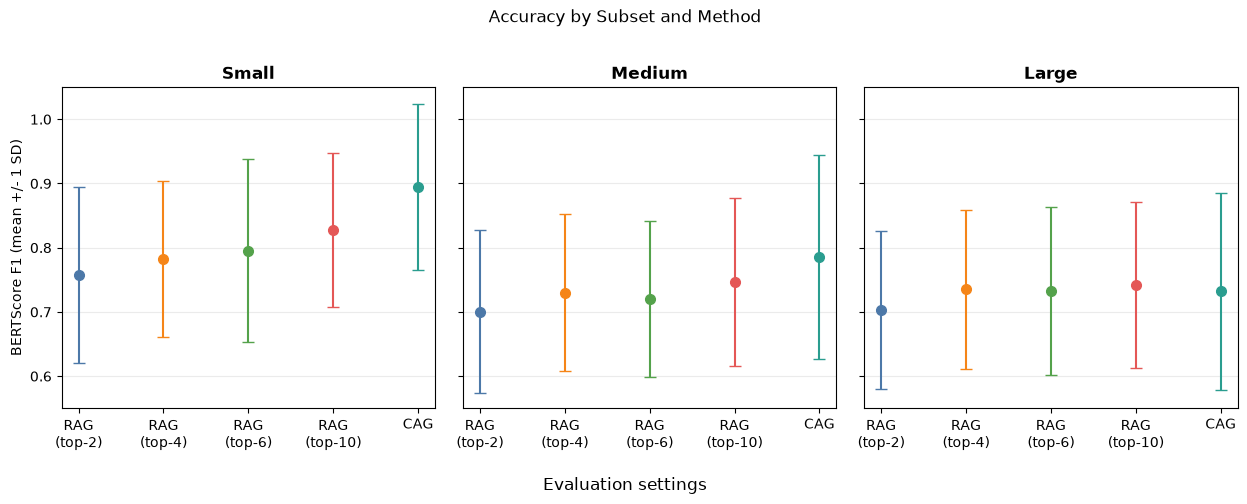

In [19]:
import json

import matplotlib.pyplot as plt
import pandas as pd

summary_files = sorted(RESULT_DIR.glob('*_summary.json'))
summaries = [json.loads(path.read_text(encoding='utf-8')) for path in summary_files]
summaries_df = pd.DataFrame(summaries)

if summaries_df.empty:
    raise RuntimeError('No saved experiment summaries found in result/.')

subset_order = [subset for subset in ('small', 'medium', 'large') if subset in set(summaries_df['subset'])]
subset_labels = {
    'small': 'Small',
    'medium': 'Medium',
    'large': 'Large',
}

for column in (
    'mean_bertscore_f1',
    'mean_retrieval_seconds',
    'mean_cache_reset_seconds',
    'mean_generation_seconds',
    'mean_online_latency_seconds',
    'std_bertscore_f1',
    'std_online_latency_seconds',
):
    if column not in summaries_df:
        summaries_df[column] = 0.0
    summaries_df[column] = pd.to_numeric(summaries_df[column], errors='coerce').fillna(0.0)

# Accuracy by subset; each panel compares methods within one subset.
rag_summaries = summaries_df[summaries_df['method'].eq('rag')].copy()
cag_summaries = summaries_df[summaries_df['method'].eq('cag')].copy()
top_ks = sorted(rag_summaries['top_k'].dropna().unique())
method_labels = [f'RAG\n(top-{int(top_k)})' for top_k in top_ks] + ['CAG']
colors = ['#4c78a8', '#f58518', '#54a24b', '#e45756', '#2a9d8f']
fig, axes = plt.subplots(1, len(subset_order), figsize=(4.2 * len(subset_order), 4.8), sharey=True)
if len(subset_order) == 1:
    axes = [axes]

for ax, subset in zip(axes, subset_order):
    rag_rows = rag_summaries[rag_summaries['subset'].eq(subset)].set_index('top_k')
    cag_rows = cag_summaries[cag_summaries['subset'].eq(subset)]
    means = [rag_rows.loc[top_k, 'mean_bertscore_f1'] for top_k in top_ks]
    errors = [rag_rows.loc[top_k, 'std_bertscore_f1'] for top_k in top_ks]
    means.append(cag_rows['mean_bertscore_f1'].iloc[0])
    errors.append(cag_rows['std_bertscore_f1'].iloc[0])
    positions = list(range(len(method_labels)))
    for position, mean, error, color in zip(positions, means, errors, colors):
        ax.errorbar(position, mean, yerr=error, fmt='o', markersize=7, color=color, ecolor=color, capsize=4, linewidth=1.5)
    ax.set_title(subset_labels[subset], fontweight='bold')
    ax.set_xticks(positions, method_labels)
    ax.grid(axis='y', alpha=0.25)
    ax.set_ylim(0.55, 1.05)

axes[0].set_ylabel('BERTScore F1 (mean +/- 1 SD)')
fig.suptitle('Accuracy by Subset and Method', y=1.02)
fig.supxlabel('Evaluation settings')
fig.tight_layout()
plt.show()

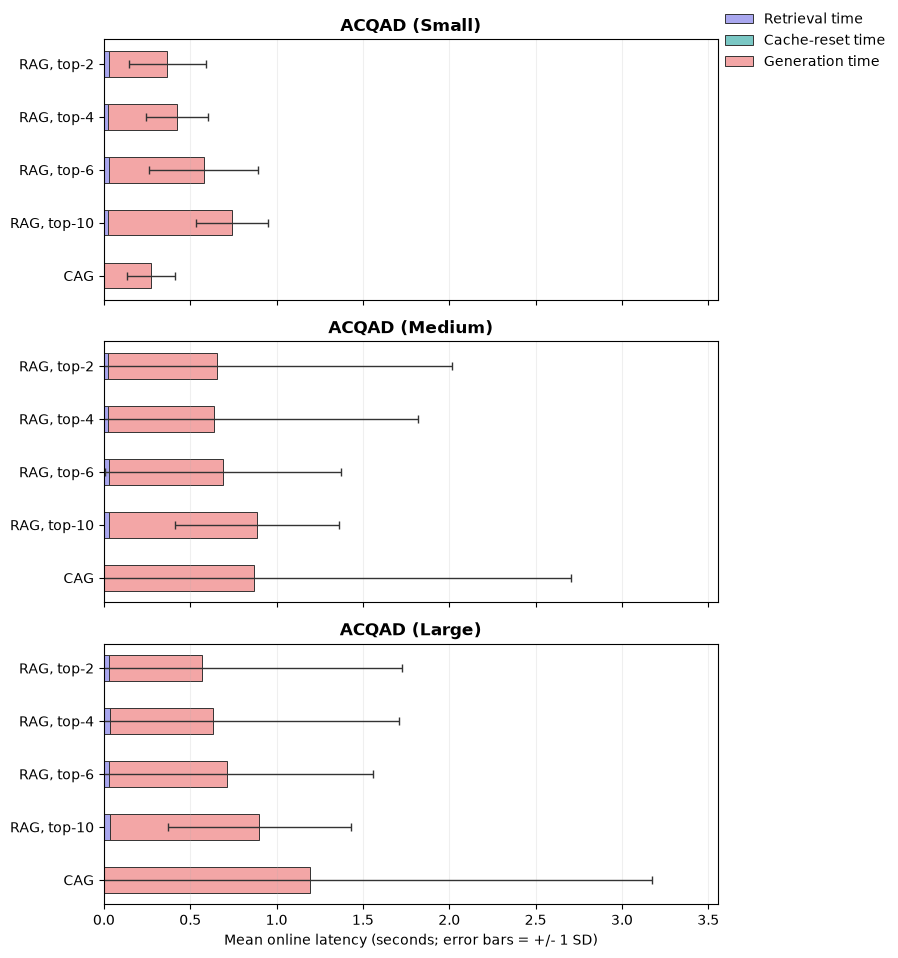

In [17]:
# Show the retrieval/cache-reset and generation components of online latency.
latency_df = summaries_df.copy()
latency_df['retrieval'] = latency_df['mean_retrieval_seconds']
latency_df['cache_reset'] = latency_df['mean_cache_reset_seconds']
latency_df['generation'] = latency_df['mean_generation_seconds']
components = [
    ('retrieval', 'Retrieval time', '#a9a7ef'),
    ('cache_reset', 'Cache-reset time', '#7ac7c4'),
    ('generation', 'Generation time', '#f3a6a6'),
]
latency_max = (latency_df[['retrieval', 'cache_reset', 'generation']].sum(axis=1) + latency_df['std_online_latency_seconds']).max()
fig, axes = plt.subplots(len(subset_order), 1, figsize=(9, 3.2 * len(subset_order)), sharex=True)
if len(subset_order) == 1:
    axes = [axes]

for ax, subset in zip(axes, subset_order):
    rag_rows = latency_df[latency_df['method'].eq('rag') & latency_df['subset'].eq(subset)].sort_values('top_k')
    cag_rows = latency_df[latency_df['method'].eq('cag') & latency_df['subset'].eq(subset)]
    plot_rows = pd.concat([rag_rows, cag_rows], ignore_index=True)
    labels = [f"RAG, top-{int(row.top_k)}" if row.method == 'rag' else 'CAG' for row in plot_rows.itertuples()]
    left = pd.Series(0.0, index=plot_rows.index)
    for column, label, color in components:
        ax.barh(labels, plot_rows[column], left=left, height=0.48, color=color, edgecolor='#333333', linewidth=0.7, label=label)
        left += plot_rows[column]
    ax.errorbar(
        left,
        plot_rows.index,
        xerr=plot_rows['std_online_latency_seconds'],
        fmt='none',
        ecolor='#333333',
        capsize=3,
        linewidth=1,
    )
    ax.set_title(f"ACQAD ({subset_labels[subset]})", fontweight='bold')
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.2)
    ax.set_xlim(0, latency_max * 1.12)

axes[-1].set_xlabel('Mean online latency (seconds; error bars = +/- 1 SD)')
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', frameon=False)
fig.tight_layout(rect=(0, 0, 0.82, 1))
plt.show()

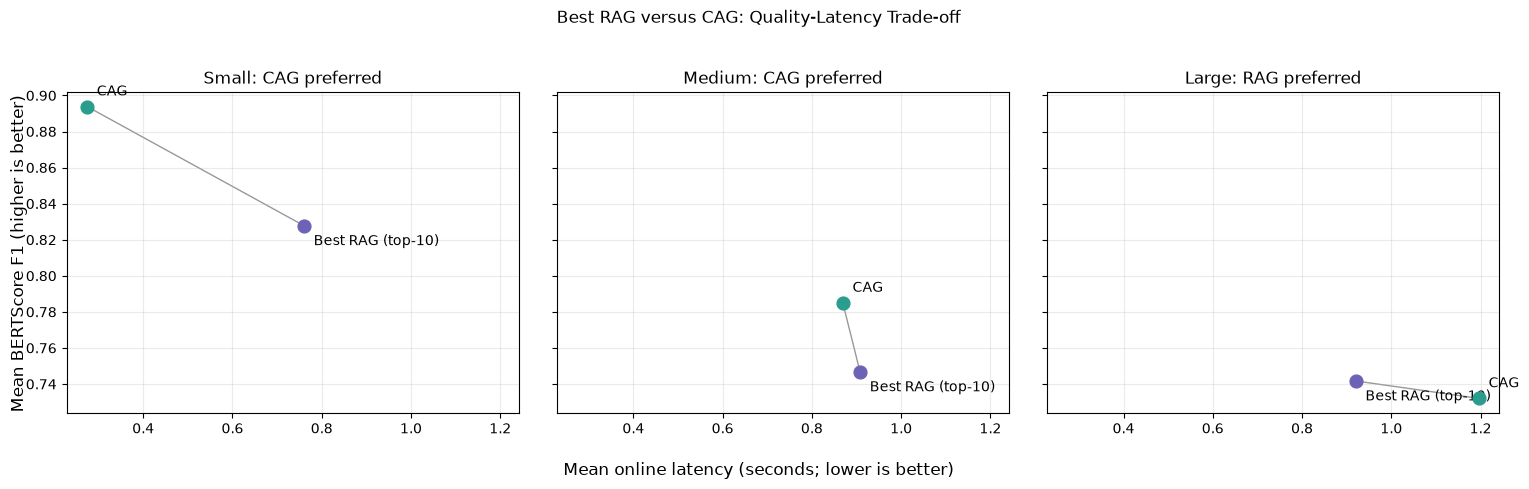

,subset,method,mean_bertscore_f1,median_bertscore_f1,std_bertscore_f1,mean_online_latency_seconds,median_online_latency_seconds,std_online_latency_seconds,outcome
4,large,Best RAG (top-10),0.7417,0.7318,0.1288,0.9202,0.8204,0.5315,RAG preferred
5,large,CAG,0.7320,0.7112,0.1533,1.1963,0.6396,1.9784,RAG preferred
2,medium,Best RAG (top-10),0.7467,0.7440,0.1307,0.9079,0.7991,0.4726,CAG preferred
3,medium,CAG,0.7850,0.7795,0.1588,0.8693,0.4042,1.8358,CAG preferred
0,small,Best RAG (top-10),0.8278,0.8137,0.1196,0.7602,0.6936,0.2074,CAG preferred
1,small,CAG,0.8938,0.9485,0.1291,0.2743,0.2553,0.1395,CAG preferred


In [18]:
# Select the highest-accuracy RAG result in each subset; break ties by lower online latency.
comparison_rows = []
for subset in subset_order:
    subset_rag = rag_summaries[rag_summaries['subset'].eq(subset)].sort_values(
        ['mean_bertscore_f1', 'mean_online_latency_seconds', 'top_k'],
        ascending=[False, True, True],
    )
    subset_cag = cag_summaries[cag_summaries['subset'].eq(subset)]
    if subset_rag.empty or subset_cag.empty:
        continue
    best_rag = subset_rag.iloc[0]
    cag = subset_cag.iloc[0]
    if cag.mean_bertscore_f1 >= best_rag.mean_bertscore_f1 and cag.mean_online_latency_seconds <= best_rag.mean_online_latency_seconds:
        outcome = 'CAG preferred'
    elif best_rag.mean_bertscore_f1 >= cag.mean_bertscore_f1 and best_rag.mean_online_latency_seconds <= cag.mean_online_latency_seconds:
        outcome = 'RAG preferred'
    else:
        outcome = 'Trade-off'
    comparison_rows.extend([
        {
            'subset': subset,
            'method': f"Best RAG (top-{int(best_rag.top_k)})",
            'mean_bertscore_f1': best_rag.mean_bertscore_f1,
            'median_bertscore_f1': best_rag.median_bertscore_f1,
            'std_bertscore_f1': best_rag.std_bertscore_f1,
            'mean_online_latency_seconds': best_rag.mean_online_latency_seconds,
            'median_online_latency_seconds': best_rag.median_online_latency_seconds,
            'std_online_latency_seconds': best_rag.std_online_latency_seconds,
            'outcome': outcome,
        },
        {
            'subset': subset,
            'method': 'CAG',
            'mean_bertscore_f1': cag.mean_bertscore_f1,
            'median_bertscore_f1': cag.median_bertscore_f1,
            'std_bertscore_f1': cag.std_bertscore_f1,
            'mean_online_latency_seconds': cag.mean_online_latency_seconds,
            'median_online_latency_seconds': cag.median_online_latency_seconds,
            'std_online_latency_seconds': cag.std_online_latency_seconds,
            'outcome': outcome,
        },
    ])

comparison_df = pd.DataFrame(comparison_rows)
fig, axes = plt.subplots(1, len(subset_order), figsize=(5.2 * len(subset_order), 4.6), sharex=True, sharey=True)
if len(subset_order) == 1:
    axes = [axes]

for ax, subset in zip(axes, subset_order):
    points = comparison_df[comparison_df['subset'].eq(subset)]
    colors = {'CAG': '#2a9d8f', **{method: '#6c63b6' for method in points['method'] if method != 'CAG'}}
    for point in points.itertuples():
        ax.scatter(point.mean_online_latency_seconds, point.mean_bertscore_f1, s=85, color=colors[point.method], zorder=3)
        label_offset = (7, 8) if point.method == 'CAG' else (7, -14)
        ax.annotate(point.method, (point.mean_online_latency_seconds, point.mean_bertscore_f1), xytext=label_offset, textcoords='offset points')
    ax.plot(points['mean_online_latency_seconds'], points['mean_bertscore_f1'], color='#999999', linewidth=1, zorder=1)
    ax.set_title(f"{subset_labels[subset]}: {points['outcome'].iat[0]}")
    ax.grid(alpha=0.25)

fig.supxlabel('Mean online latency (seconds; lower is better)')
fig.supylabel('Mean BERTScore F1 (higher is better)')
fig.suptitle('Best RAG versus CAG: Quality-Latency Trade-off', y=1.03)
fig.tight_layout()
plt.show()

comparison_table = comparison_df[[
    'subset', 'method',
    'mean_bertscore_f1', 'median_bertscore_f1', 'std_bertscore_f1',
    'mean_online_latency_seconds', 'median_online_latency_seconds', 'std_online_latency_seconds',
    'outcome',
]].sort_values(['subset', 'method'])
display(comparison_table.style.format({
    'mean_bertscore_f1': '{:.4f}',
    'median_bertscore_f1': '{:.4f}',
    'std_bertscore_f1': '{:.4f}',
    'mean_online_latency_seconds': '{:.4f}',
    'median_online_latency_seconds': '{:.4f}',
    'std_online_latency_seconds': '{:.4f}',
}))

## Smoke Test

In [8]:
# rag_rows, rag_summary = run_rag('small', top_k=2, limit=1)
# cag_rows, cag_summary = run_cag('small', limit=1)
# display(rag_summary)
# display(cag_summary)

## View Saved Summaries

In [9]:
summaries_df.sort_values(['method', 'subset', 'top_k'], na_position='last')

,method,subset,top_k,created_at,questions,mean_bertscore_f1,mean_cache_reset_seconds,mean_generation_seconds,mean_online_latency_seconds,median_online_latency_seconds,min_online_latency_seconds,max_online_latency_seconds,total_online_latency_seconds,mean_generated_tokens,total_generated_tokens,mean_tokens_per_second,prepare_seconds,prefix_tokens,knowledge_passages,mean_retrieval_seconds
0,cag,large,NaN,2026-07-18T17:26:59.279323+00:00,31,0.698294,0.000266,1.065502,1.066690,0.548899,0.434887,7.742232,33.067377,15.903226,493,11.402231,20.375397,89624.0,200.0,0.000000
1,cag,medium,NaN,2026-07-18T17:23:27.295785+00:00,21,0.749853,0.000239,0.487656,0.488649,0.336815,0.253075,2.115201,10.261630,8.333333,175,13.897218,9.526643,56420.0,130.0,0.000000
2,cag,small,NaN,2026-07-18T17:21:13.213147+00:00,8,0.909486,0.000244,0.275752,0.279576,0.235888,0.176392,0.591400,2.236604,4.875000,39,18.970118,4.458052,29664.0,60.0,0.000000
4,rag,large,2.0,2026-07-18T17:27:35.371419+00:00,31,0.717212,0.000000,0.603896,0.641358,0.326065,0.151453,8.815442,19.882106,18.193548,564,25.110822,1.330288,NaN,NaN,0.032660
5,rag,large,4.0,2026-07-18T17:28:08.145833+00:00,31,0.719695,0.000000,0.489277,0.532157,0.417556,0.239824,2.813318,16.496854,10.967742,340,19.404894,1.318773,NaN,NaN,0.034103
6,rag,large,6.0,2026-07-18T17:28:41.641225+00:00,31,0.711327,0.000000,0.536473,0.581376,0.494907,0.292756,1.295545,18.022646,9.580645,297,16.252758,1.322583,NaN,NaN,0.033109
3,rag,large,10.0,2026-07-18T17:29:27.074593+00:00,31,0.723314,0.000000,0.904370,0.954792,0.828766,0.529916,2.836224,29.598545,14.129032,438,13.558906,1.318728,NaN,NaN,0.032676
8,rag,medium,2.0,2026-07-18T17:23:57.381047+00:00,21,0.729605,0.000000,0.700092,0.732421,0.310899,0.143931,8.821427,15.380849,21.904762,460,26.571498,0.792768,NaN,NaN,0.027876
9,rag,medium,4.0,2026-07-18T17:24:23.409082+00:00,21,0.743013,0.000000,0.477214,0.510971,0.398169,0.221792,2.702534,10.730398,11.904762,250,21.191728,0.798019,NaN,NaN,0.026664
10,rag,medium,6.0,2026-07-18T17:24:53.275452+00:00,21,0.724479,0.000000,0.646861,0.687777,0.459069,0.334511,3.272372,14.443322,13.142857,276,16.230594,0.803131,NaN,NaN,0.029160
